In [1]:
import matplotlib.pyplot as plt
import numpy as np

from mpl_toolkits.basemap import Basemap

import xarray as xr
import pandas as pd
import cmocean
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import matplotlib.colors as colors

from mpl_toolkits.axes_grid1 import AxesGrid
from mpl_toolkits.basemap import Basemap

In [2]:

# ds1 = xr.open_dataset('/media/athira/One Touch/final_datasets/analysis_biascorrected_outputs/ph_ens_ssp585_biascorrected_mean.nc').squeeze()
# ds1=xr.open_dataset('/media/athira/One Touch/final_datasets/analysis_biascorrected_outputs/ph_ens_ssp585_biascorrected_mean.nc').squeeze()
ds1 = xr.open_dataset('/media/athira/One Touch/final_datasets/Edited_plots/merged_files/ph_ens_ssp585_biascorrected_mean.nc')


ds1 = 10**(-1*ds1)

ds1 = ds1*10**(9)


In [3]:
lat_range = slice(-18, 0)  # Latitude range from -30 to 30
lon_range = slice(30, 120)  # Longitude range from 30 to 100

ds1_hist  = ds1.sel(lat=lat_range, lon=lon_range, time=slice('1985', '2014'))#.mean(['lat', 'lon'])
ds1_hist_avg= ds1_hist.mean(['lat', 'lon'])




In [4]:
da = ds1_hist_avg['ph']   # assuming your DataArray is called `ph`
import xrft as xt
# Create numeric time axis
da_detrended = xt.detrend(
    da,
    dim="time",
    detrend_type="linear"
)

# -----------------------------
# Step 4: Restore NaNs
# -----------------------------
# da_detrended = da_detrended.where(da.notnull())


In [24]:
# da_detrended.mean()

In [25]:
# hist_detrend  = da_detrended.sel(time=slice('1985', '2014'))#.mean(['lat', 'lon'])

threshold= da_detrended.quantile(
    0.95, dim="time", skipna=True
)
threshold

<xarray.DataArray 'ph' ()> Size: 8B
array(0.17515893)
Coordinates:
    quantile  float64 8B 0.95

In [26]:
hotspot_ph = da_detrended.where(da_detrended > threshold, drop=True)

In [27]:
hotspot_ph.mean()

<xarray.DataArray 'ph' ()> Size: 8B
array(0.20877556)
Coordinates:
    DEPTH1_1  float32 4B 0.0
    TIME      datetime64[ns] 8B 2017-01-01
    lev       float64 8B 500.0
    olevel    float32 4B 0.5058
    quantile  float64 8B 0.95

In [28]:
# lat_range = slice(-30, -18)  # Latitude range from -30 to 30
# lon_range = slice(30, 120)  # Longitude range from 30 to 100

ds1_nf  = ds1.sel(lat=lat_range, lon=lon_range, time=slice('2015', '2040'))#.mean(['lat', 'lon'])
ds1_nf_avg= ds1_nf.mean(['lat', 'lon'])

da_nf = ds1_nf_avg['ph']   # assuming your DataArray is called `ph`
import xrft as xt
# Create numeric time axis
da_detrended_nf = xt.detrend(
    da_nf,
    dim="time",
    detrend_type="linear"
)
hotspot_ph_nf = da_detrended_nf.where(da_detrended_nf > threshold, drop=True)

hotspot_ph_nf.mean()

<xarray.DataArray 'ph' ()> Size: 8B
array(0.22732751)
Coordinates:
    DEPTH1_1  float32 4B 0.0
    TIME      datetime64[ns] 8B 2017-01-01
    lev       float64 8B 500.0
    olevel    float32 4B 0.5058
    quantile  float64 8B 0.95

In [29]:
# lat_range = slice(-30, -18)  # Latitude range from -30 to 30
# lon_range = slice(30, 120)  # Longitude range from 30 to 100

ds1_nf  = ds1.sel(lat=lat_range, lon=lon_range, time=slice('2041', '2070'))#.mean(['lat', 'lon'])
ds1_nf_avg= ds1_nf.mean(['lat', 'lon'])

da_nf = ds1_nf_avg['ph']   # assuming your DataArray is called `ph`
import xrft as xt
# Create numeric time axis
da_detrended_nf = xt.detrend(
    da_nf,
    dim="time",
    detrend_type="linear"
)
hotspot_ph_nf = da_detrended_nf.where(da_detrended_nf > threshold, drop=True)

hotspot_ph_nf.mean()

<xarray.DataArray 'ph' ()> Size: 8B
array(0.29496389)
Coordinates:
    DEPTH1_1  float32 4B 0.0
    TIME      datetime64[ns] 8B 2017-01-01
    lev       float64 8B 500.0
    olevel    float32 4B 0.5058
    quantile  float64 8B 0.95

In [30]:
# lat_range = slice(-30, -18)  # Latitude range from -30 to 30
# lon_range = slice(30, 120)  # Longitude range from 30 to 100

ds1_nf  = ds1.sel(lat=lat_range, lon=lon_range, time=slice('2071', '2100'))#.mean(['lat', 'lon'])
ds1_nf_avg= ds1_nf.mean(['lat', 'lon'])

da_nf = ds1_nf_avg['ph']   # assuming your DataArray is called `ph`
import xrft as xt
# Create numeric time axis
da_detrended_nf = xt.detrend(
    da_nf,
    dim="time",
    detrend_type="linear"
)
hotspot_ph_nf = da_detrended_nf.where(da_detrended_nf > threshold, drop=True)

hotspot_ph_nf.mean()

<xarray.DataArray 'ph' ()> Size: 8B
array(0.27976893)
Coordinates:
    DEPTH1_1  float32 4B 0.0
    TIME      datetime64[ns] 8B 2017-01-01
    lev       float64 8B 500.0
    olevel    float32 4B 0.5058
    quantile  float64 8B 0.95

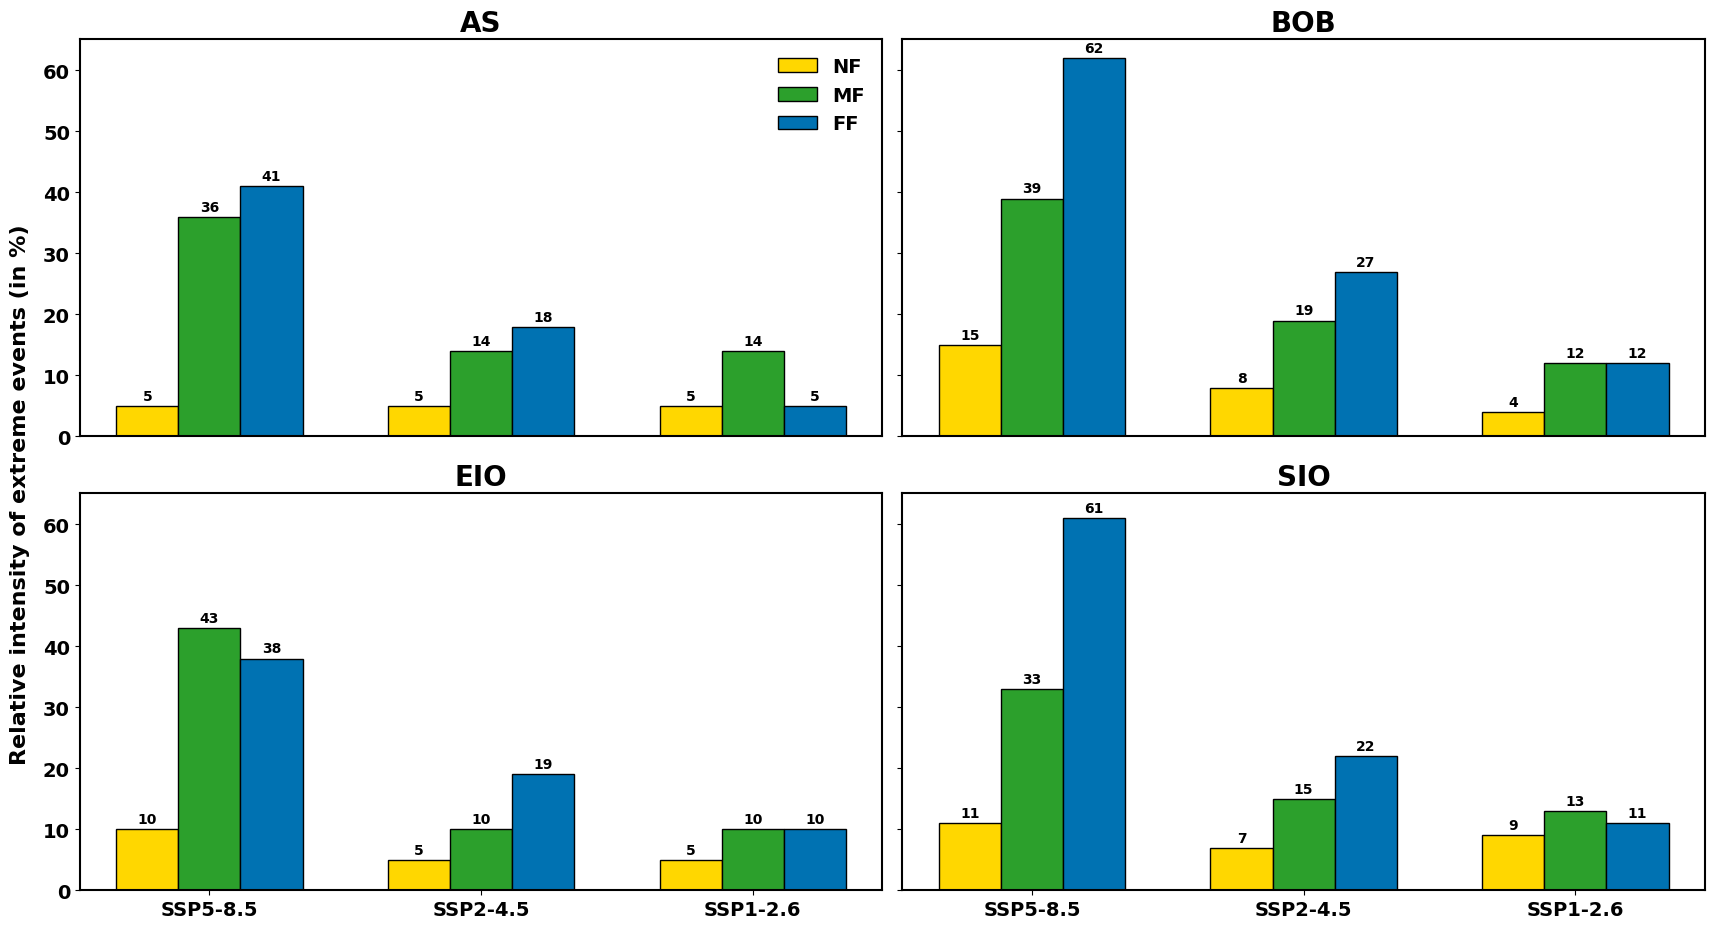

In [33]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Global style
# -----------------------------
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.titleweight'] = 'bold'

# -----------------------------
# Data
# -----------------------------
scenarios = ['SSP5-8.5', 'SSP2-4.5', 'SSP1-2.6']
periods   = ['NF', 'MF', 'FF']

# Bright, publication-safe colors
colors = {
    'NF': '#FFD700',   # gold
    'MF': '#2CA02C',   # vivid green
    'FF': '#0072B2'    # strong blue
}

data = {
    'AS': {
        'SSP5-8.5': [5, 36, 41],
        'SSP2-4.5': [5, 14, 18],
        'SSP1-2.6': [5, 14, 5]
    },
    'BOB': {
        'SSP5-8.5': [15, 39, 62],
        'SSP2-4.5': [8, 19, 27],
        'SSP1-2.6': [4, 12, 12]
    },
    'EIO': {
        'SSP5-8.5': [10, 43, 38],
        'SSP2-4.5': [5, 10, 19],
        'SSP1-2.6': [5, 10, 10]
    },
    'SIO': {
        'SSP5-8.5': [11, 33, 61],
        'SSP2-4.5': [7, 15, 22],
        'SSP1-2.6': [9, 13, 11]
    }
}

# -----------------------------
# Plot setup
# -----------------------------
fig, axes = plt.subplots(2, 2, figsize=(18, 10), sharey=True)
axes = axes.flatten()

bar_width = 0.16  # DO NOT change

# Custom x positions:
# reduced gap between SSP5-8.5 and SSP2-4.5
x = np.array([0.0, 0.7, 1.4])

# -----------------------------
# Plot each region
# -----------------------------
for idx, (ax, (region, region_data)) in enumerate(zip(axes, data.items())):

    row = idx // 2
    col = idx % 2

    for i, period in enumerate(periods):
        values = [region_data[sc][i] for sc in scenarios]

        bars = ax.bar(
            x + i * bar_width,
            values,
            width=bar_width,
            color=colors[period],
            edgecolor='black',
            linewidth=1.0,
            label=period
        )

        # Value labels
        for bar in bars:
            h = bar.get_height()
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                h + 0.5,
                f'{int(h)}',
                ha='center',
                va='bottom',
                fontsize=10,
                fontweight='bold'
            )

    # Axis styling
    ax.set_title(region, fontsize=20)

    for spine in ax.spines.values():
        spine.set_linewidth(1.5)

    # X-axis labels only for bottom row
    if row == 1:
        ax.set_xticks(x + bar_width)
        ax.set_xticklabels(scenarios, fontsize=14, fontweight='bold')
    else:
        ax.set_xticks([])

    # Y-axis
    ax.tick_params(axis='y', labelsize=14)
    if col != 0:
        ax.tick_params(axis='y', labelleft=False)

# -----------------------------
# Common labels & legend
# -----------------------------
fig.text(
    0.05, 0.5,
    'Relative intensity of extreme events (in %)',
    va='center',
    rotation='vertical',
    fontsize=16,
    fontweight='bold'
)

axes[0].legend(
    fontsize=14,
    frameon=False
)

# -----------------------------
# Save & show
# -----------------------------
plt.tight_layout(rect=[0.06, 0.06, 1, 1])
plt.savefig(
    "Intensity_extremes_regional_v1_bc.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


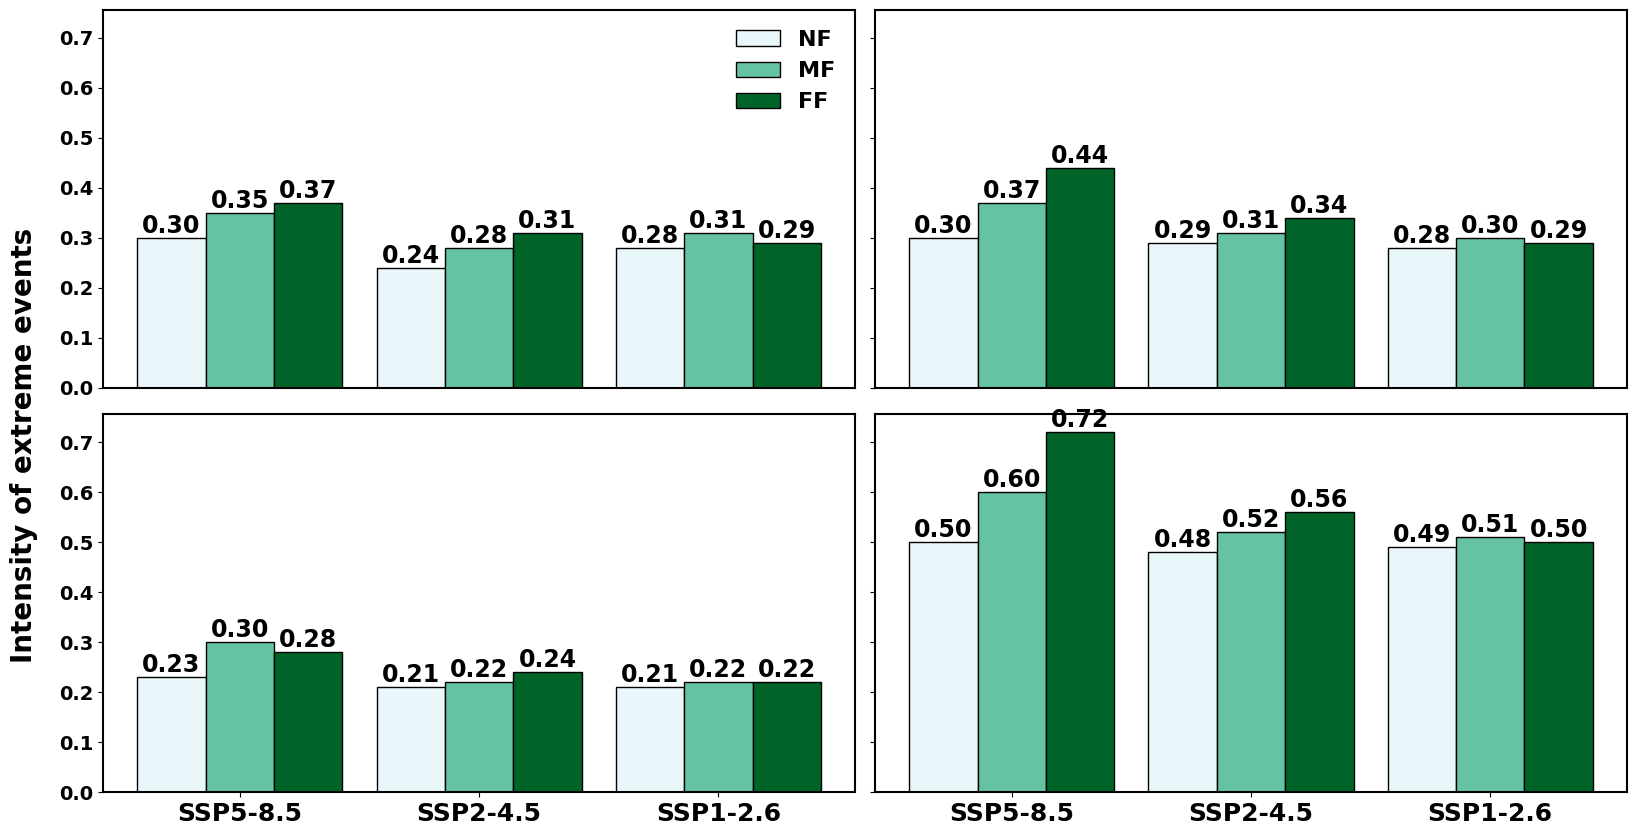

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Global style
# -----------------------------
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.titleweight'] = 'bold'

# -----------------------------
# Data
# -----------------------------
scenarios = ['SSP5-8.5', 'SSP2-4.5', 'SSP1-2.6']
periods   = ['NF', 'MF', 'FF']

# Bright, publication-safe colors
# colors = {
#     'NF': '#FFD700',   # gold
#     'MF': '#2CA02C',   # vivid green
#     'FF': '#0072B2'    # strong blue
# }
# colors = {
#     'NF': '#D55E00',   # vermillion
#     'MF': '#009E73',   # teal green
#     'FF': '#CC79A7'    # reddish purple
# }

cmap = plt.get_cmap('BuGn')
color_list = cmap(np.linspace(0.1, 0.9, 3))
colors = dict(zip(periods, color_list))


data = {
    'AS': {
        'SSP5-8.5': [0.30, 0.35, 0.37],
        'SSP2-4.5': [0.24, 0.28, 0.31],
        'SSP1-2.6': [0.28, 0.31, 0.29]
    },
    'BOB': {
        'SSP5-8.5': [0.30, 0.37, 0.44],
        'SSP2-4.5': [0.29, 0.31, 0.34],
        'SSP1-2.6': [0.28, 0.30, 0.29]
    },
    'EIO': {
        'SSP5-8.5': [0.23, 0.30, 0.28],
        'SSP2-4.5': [0.21, 0.22, 0.24],
        'SSP1-2.6': [0.21, 0.22, 0.22]
    },
    'SIO': {
        'SSP5-8.5': [0.50, 0.60, 0.72],
        'SSP2-4.5': [0.48, 0.52, 0.56],
        'SSP1-2.6': [0.49, 0.51, 0.50]
    }
}

# -----------------------------
# Plot setup
# -----------------------------
fig, axes = plt.subplots(2, 2, figsize=(17, 9), sharey=True)
axes = axes.flatten()

bar_width = 0.2  # DO NOT change

# Custom x positions:
# reduced gap between SSP5-8.5 and SSP2-4.5
x = np.array([0.0, 0.7, 1.4])

# -----------------------------
# Plot each region
# -----------------------------
for idx, (ax, (region, region_data)) in enumerate(zip(axes, data.items())):

    row = idx // 2
    col = idx % 2

    for i, period in enumerate(periods):
        values = [region_data[sc][i] for sc in scenarios]

        bars = ax.bar(
            x + i * bar_width,
            values,
            width=bar_width,
            color=colors[period],
            edgecolor='black',
            linewidth=1.0,
            label=period
        )

        # Value labels
        for bar in bars:
            h = bar.get_height()
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                h + 0.0,
                f'{h:.2f}',   # <-- keep two decimals
                # f'{int(h)}',
                ha='center',
                va='bottom',
                fontsize=17,
                fontweight='bold'
            )

    # Axis styling
    # ax.set_title(region, fontsize=16)

    for spine in ax.spines.values():
        spine.set_linewidth(1.5)

    # X-axis labels only for bottom row
    if row == 1:
        ax.set_xticks(x + bar_width)
        ax.set_xticklabels(scenarios, fontsize=18, fontweight='bold')
    else:
        ax.set_xticks([])

    # Y-axis
    ax.tick_params(axis='y', labelsize=14)
    if col != 0:
        ax.tick_params(axis='y', labelleft=False)

# -----------------------------
# Common labels & legend
# -----------------------------
fig.text(
    0.04, 0.5,
    'Intensity of extreme events',
    va='center',
    rotation='vertical',
    fontsize=20,
    fontweight='bold'
)

axes[0].legend(
    fontsize=16,
    frameon=False
)

# -----------------------------
# Save & show
# -----------------------------
plt.tight_layout(rect=[0.06, 0.06, 1, 1])
# plt.savefig(
#     "Intensity_extremes_r1.png",
#     dpi=300,
#     bbox_inches="tight"
# )
plt.show()


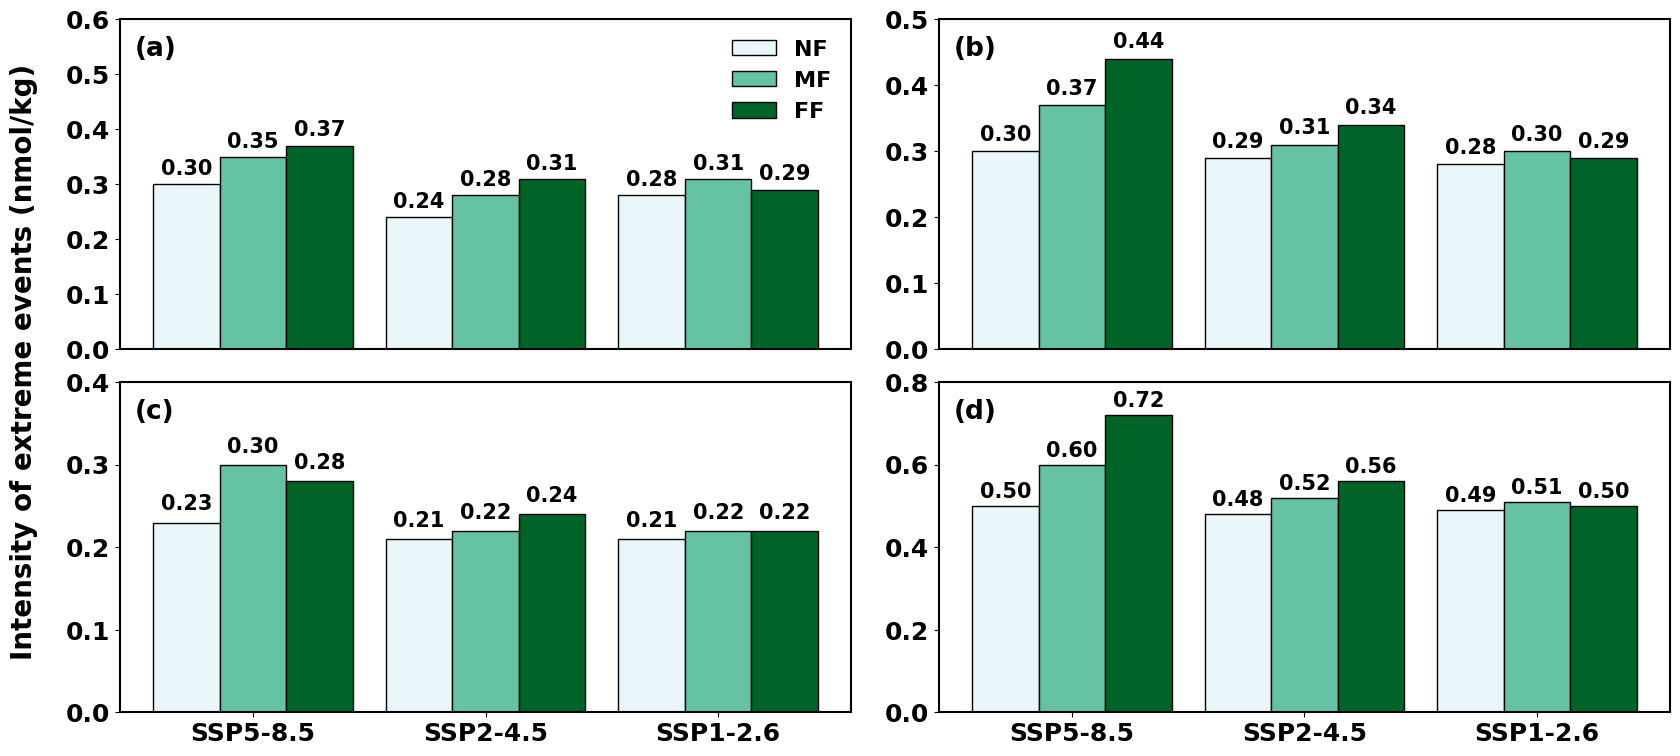

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Global style
# -----------------------------
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.titleweight'] = 'bold'

# -----------------------------
# Data
# -----------------------------
scenarios = ['SSP5-8.5', 'SSP2-4.5', 'SSP1-2.6']
periods   = ['NF', 'MF', 'FF']

# Colormap
cmap = plt.get_cmap('BuGn')
color_list = cmap(np.linspace(0.1, 0.9, 3))
colors = dict(zip(periods, color_list))

data = {
    'AS': {
        'SSP5-8.5': [0.30, 0.35, 0.37],
        'SSP2-4.5': [0.24, 0.28, 0.31],
        'SSP1-2.6': [0.28, 0.31, 0.29]
    },
    'BOB': {
        'SSP5-8.5': [0.30, 0.37, 0.44],
        'SSP2-4.5': [0.29, 0.31, 0.34],
        'SSP1-2.6': [0.28, 0.30, 0.29]
    },
    'EIO': {
        'SSP5-8.5': [0.23, 0.30, 0.28],
        'SSP2-4.5': [0.21, 0.22, 0.24],
        'SSP1-2.6': [0.21, 0.22, 0.22]
    },
    'SIO': {
        'SSP5-8.5': [0.50, 0.60, 0.72],
        'SSP2-4.5': [0.48, 0.52, 0.56],
        'SSP1-2.6': [0.49, 0.51, 0.50]
    }
}

# -----------------------------
# Plot setup
# -----------------------------
fig, axes = plt.subplots(2, 2, figsize=(20, 9))
axes = axes.flatten()

bar_width = 0.2
x = np.array([0.0, 0.7, 1.4])

panel_labels = ['(a)', '(b)', '(c)', '(d)']

# -----------------------------
# Plot
# -----------------------------
for idx, (ax, (region, region_data)) in enumerate(zip(axes, data.items())):

    row = idx // 2
    col = idx % 2

    for i, period in enumerate(periods):
        values = [region_data[sc][i] for sc in scenarios]

        bars = ax.bar(
            x + i * bar_width,
            values,
            width=bar_width,
            color=colors[period],
            edgecolor='black',
            linewidth=1.0,
            label=period
        )

        # Value labels
        for bar in bars:
            h = bar.get_height()
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                h + 0.01,
                f'{h:.2f}',
                ha='center',
                va='bottom',
                fontsize=15,
                fontweight='bold'
            )

    # -----------------------------
    # Panel labels (a–d)
    # -----------------------------
    ax.text(
        0.02, 0.95,
        panel_labels[idx],
        transform=ax.transAxes,
        fontsize=19,
        fontweight='bold',
        va='top'
    )

    # -----------------------------
    # Y-limits and ticks
    # -----------------------------
    if idx == 0:
        ax.set_ylim(0, 0.6)
        ax.set_yticks(np.arange(0, 0.61, 0.1))
    elif idx == 1:
        ax.set_ylim(0, 0.5)
        ax.set_yticks(np.arange(0, 0.51, 0.1))
    elif idx == 2:
        ax.set_ylim(0, 0.4)
        ax.set_yticks(np.arange(0, 0.41, 0.1))
    else:
        ax.set_ylim(0, 0.8)
        ax.set_yticks(np.arange(0, 0.81, 0.2))

    ax.tick_params(axis='y', labelsize=18)

    # -----------------------------
    # X-axis ticks
    # -----------------------------
    if row == 1:
        ax.set_xticks(x + bar_width)
        ax.set_xticklabels(scenarios, fontsize=18, fontweight='bold')
    else:
        ax.set_xticks([])

    # Spine styling
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)

# -----------------------------
# Common label & legend
# -----------------------------
fig.text(
    0.07, 0.5,
    'Intensity of extreme events (nmol/kg)',
    va='center',
    rotation='vertical',
    fontsize=20,
    fontweight='bold'
)

axes[0].legend(fontsize=16, frameon=False)

# -----------------------------
# Layout (increase vertical gap)
# -----------------------------
plt.subplots_adjust(
    hspace=0.10,   # ↑ increases gap between rows (key change)
    wspace=0.12
)

plt.savefig(
    "Intensity_extremes_r3.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()